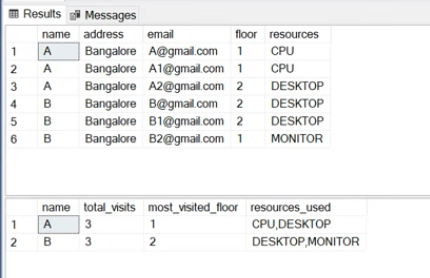

In [ ]:
with 
distinct_resources as (select distinct name, resources from entries),
agg_resources as (select name, STRING_AGG(resources,',')as used_resources from distinct_resources group by name),
total_visits as (
select name,count(1) as total_visits,STRING_AGG(resources,',') as resource_used from entries
group by name),
floor_visit as (
select 
name,floor,count(floor) as floor_count,rank() over(partition by name order by count(floor) desc) as r_n
from entries 
group by name,floor)
select fv.name,fv.floor as most_visited_floor,tv.total_visits,ar.used_resources
from floor_visit fv 
inner join total_visits tv on fv.name=tv.name 
inner join agg_resources ar on ar.name=fv.name
where r_n =1